# Chapter 126 — Scalar Multiplication

> **Prerequisites:** Vector Addition (ch125), What is a Vector? (ch121)
> **You will learn:**
> - What scalar multiplication does geometrically and algebraically
> - How negative scalars reverse direction
> - The distributive laws that connect scalar multiplication and addition
> - Why scalar multiplication is one of the two axioms underlying all of vector algebra

> **Environment:** Python 3.x, numpy, matplotlib

---

## 1. Concept

Scalar multiplication scales a vector by a real number. Multiply each component by the scalar.

$$c \mathbf{v} = \begin{pmatrix} c v_1 \\ c v_2 \\ \vdots \\ c v_n \end{pmatrix}$$

Geometrically:
- If $c > 1$: the vector grows longer, same direction.
- If $0 < c < 1$: the vector shrinks, same direction.
- If $c = -1$: the vector flips to the opposite direction, same length.
- If $c < 0$: the vector flips and scales.
- If $c = 0$: the vector collapses to the zero vector.

**Common misconception:** Scalar multiplication does not change the *direction* of a vector when $c > 0$. Direction only flips when $c < 0$. Scaling and direction change are independent effects.

---

## 2. Intuition & Mental Models

**Geometric model:** Think of a vector as a rubber band stretched in a specific direction. Multiplying by 2 doubles the stretch. Multiplying by 0.5 halves it. Multiplying by −1 flips the band to point the opposite way.

**Physical model:** A force of 10N north is the same direction as 3N north — they are scalar multiples of the same unit vector (one pointing north). Scaling the force means scaling the magnitude.

**Computational model:** Think of a vector as a template arrow. Any scalar multiple is a stretched/flipped/shrunk version of the same template, still lying on the same line through the origin.

Recall from ch125 (Vector Addition) that $-\mathbf{v}$ is the additive inverse. That is exactly $(-1) \cdot \mathbf{v}$ — scalar multiplication with $c = -1$.

---

## 3. Visualization

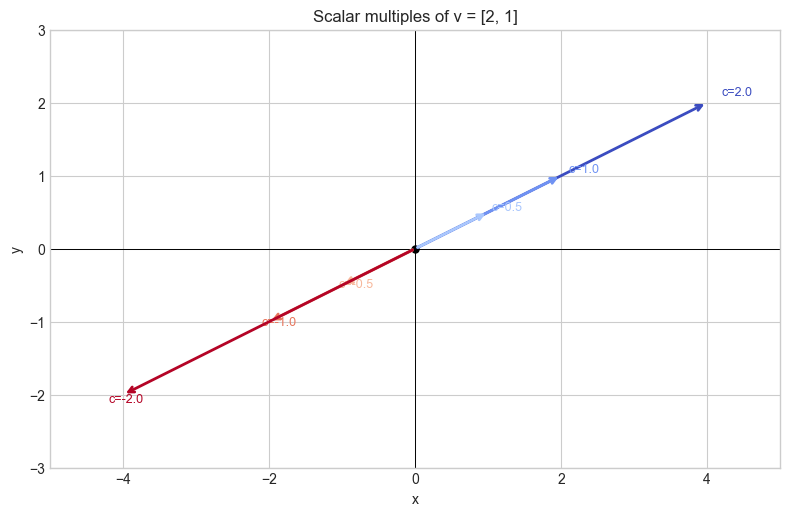

In [1]:
# --- Visualization: Effect of different scalars on a vector ---
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

v = np.array([2.0, 1.0])
scalars = [2.0, 1.0, 0.5, 0.0, -0.5, -1.0, -2.0]

colors = plt.cm.coolwarm(np.linspace(0, 1, len(scalars)))

fig, ax = plt.subplots(figsize=(8, 6))

for c, color in zip(scalars, colors):
    scaled = c * v
    ax.annotate('', xy=scaled, xytext=[0, 0],
                arrowprops=dict(arrowstyle='->', color=color, lw=2.0))
    if c != 0:
        ax.text(scaled[0]*1.05, scaled[1]*1.05, f'c={c}', fontsize=9, color=color)

ax.plot(0, 0, 'ko', markersize=5)
ax.set_xlim(-5, 5); ax.set_ylim(-3, 3)
ax.axhline(0, color='black', lw=0.7); ax.axvline(0, color='black', lw=0.7)
ax.set_aspect('equal')
ax.set_title('Scalar multiples of v = [2, 1]')
ax.set_xlabel('x'); ax.set_ylabel('y')
plt.tight_layout()
plt.show()

## 4. Mathematical Formulation

**Definition.** For $c \in \mathbb{R}$ and $\mathbf{v} \in \mathbb{R}^n$:

$$(c\mathbf{v})_i = c \cdot v_i \qquad \text{for all } i$$

**Properties (Distributive laws):**

1. $c(\mathbf{u} + \mathbf{v}) = c\mathbf{u} + c\mathbf{v}$ — scalar distributes over vector addition
2. $(a + b)\mathbf{v} = a\mathbf{v} + b\mathbf{v}$ — vector distributes over scalar addition
3. $a(b\mathbf{v}) = (ab)\mathbf{v}$ — scalar multiplication is associative with scalars
4. $1 \cdot \mathbf{v} = \mathbf{v}$ — multiplicative identity

Together with vector addition properties (ch125), these eight axioms define a **vector space** *(formalized in ch137)*.

In [2]:
# --- Mathematical Formulation: verify distributive laws ---
import numpy as np

u = np.array([1.0, 3.0, -2.0])
v = np.array([2.0, -1.0, 4.0])
a, b, c = 2.5, -1.0, 3.0

print("Distributive (scalar over vector sum):")
lhs = c * (u + v)
rhs = c * u + c * v
print(f"  c*(u+v) = {lhs}")
print(f"  c*u+c*v = {rhs}")
print(f"  Equal?   {np.allclose(lhs, rhs)}")

print("\nDistributive (vector over scalar sum):")
lhs = (a + b) * v
rhs = a * v + b * v
print(f"  (a+b)*v = {lhs}")
print(f"  a*v+b*v = {rhs}")
print(f"  Equal?   {np.allclose(lhs, rhs)}")

print("\nAssociativity with scalars:")
print(f"  a*(b*v) = {a*(b*v)}")
print(f"  (a*b)*v = {(a*b)*v}")
print(f"  Equal?   {np.allclose(a*(b*v), (a*b)*v)}")

Distributive (scalar over vector sum):
  c*(u+v) = [9. 6. 6.]
  c*u+c*v = [9. 6. 6.]
  Equal?   True

Distributive (vector over scalar sum):
  (a+b)*v = [ 3.  -1.5  6. ]
  a*v+b*v = [ 3.  -1.5  6. ]
  Equal?   True

Associativity with scalars:
  a*(b*v) = [ -5.    2.5 -10. ]
  (a*b)*v = [ -5.    2.5 -10. ]
  Equal?   True


## 5. Python Implementation

In [3]:
# --- Implementation: scalar_multiply and unit vector ---
import numpy as np

def scalar_multiply(c, v):
    """
    Multiply vector v by scalar c.

    Args:
        c: float — the scalar
        v: ndarray shape (n,)

    Returns:
        ndarray shape (n,)
    """
    v = np.asarray(v, dtype=float)
    return np.array([c * vi for vi in v])


def normalize(v):
    """
    Return the unit vector in the direction of v (scale to magnitude 1).
    This is scalar multiplication by 1/||v||.

    Args:
        v: ndarray shape (n,), must be non-zero

    Returns:
        ndarray shape (n,)

    Raises:
        ValueError: if v is the zero vector
    """
    mag = np.linalg.norm(v)
    if mag < 1e-12:
        raise ValueError("Cannot normalize the zero vector.")
    return v / mag  # equivalent to scalar_multiply(1/mag, v)


v = np.array([3.0, 4.0])
scaled = scalar_multiply(2.5, v)
unit   = normalize(v)

print("v =", v)
print("2.5 * v =", scaled)
print("unit(v) =", unit, "  magnitude:", np.linalg.norm(unit))

# Verify: scalar_multiply(||v||, unit(v)) should recover v
mag = np.linalg.norm(v)
recovered = scalar_multiply(mag, unit)
print("mag * unit(v) =", recovered, " match:", np.allclose(recovered, v))

v = [3. 4.]
2.5 * v = [ 7.5 10. ]
unit(v) = [0.6 0.8]   magnitude: 1.0
mag * unit(v) = [3. 4.]  match: True


## 6. Experiments

In [4]:
# --- Experiment 1: Direction is preserved under positive scaling ---
# Hypothesis: the angle between v and c*v is 0 for c > 0, and 180° for c < 0.
# Try changing: the scalar c.
import numpy as np

v = np.array([3.0, 2.0])
C_VALUES = [3.0, 1.0, 0.1, -0.1, -1.0, -3.0]  # <-- modify

for c in C_VALUES:
    scaled = c * v
    # dot product / product of magnitudes = cos(angle)
    cos_angle = np.dot(v, scaled) / (np.linalg.norm(v) * np.linalg.norm(scaled))
    angle_deg = np.degrees(np.arccos(np.clip(cos_angle, -1, 1)))
    print(f"c={c:5.1f}  scaled={scaled}  angle={angle_deg:.1f}°")

c=  3.0  scaled=[9. 6.]  angle=0.0°
c=  1.0  scaled=[3. 2.]  angle=0.0°
c=  0.1  scaled=[0.3 0.2]  angle=0.0°
c= -0.1  scaled=[-0.3 -0.2]  angle=180.0°
c= -1.0  scaled=[-3. -2.]  angle=180.0°
c= -3.0  scaled=[-9. -6.]  angle=180.0°


In [5]:
# --- Experiment 2: Unit vectors ---
# Hypothesis: any non-zero vector divided by its norm produces a vector of length 1.
# Try changing: the vector v.
import numpy as np

v = np.array([7.0, -3.0, 2.0])  # <-- modify: try different magnitudes

unit_v = v / np.linalg.norm(v)
print("v:         ", v)
print("||v||:     ", np.linalg.norm(v))
print("unit(v):   ", unit_v)
print("||unit(v)||:", np.linalg.norm(unit_v))

v:          [ 7. -3.  2.]
||v||:      7.874007874011811
unit(v):    [ 0.88900089 -0.38100038  0.25400025]
||unit(v)||: 0.9999999999999999


## 7. Exercises

**Easy 1.** Compute $3 \cdot (2, -1, 4)$ and $(-0.5) \cdot (6, 0, -2)$ by hand, then verify with NumPy. *(Expected: (6, -3, 12) and (-3, 0, 1))*

**Easy 2.** Normalize the vector **v** = (1, 1). What is the result? What angle does it make with the x-axis? *(Expected: (0.707, 0.707), 45°)*

**Medium 1.** Write a function `scale_to_length(v, target_length)` that scales **v** to have magnitude `target_length`. Verify on **v** = (3, 4) with target 10.

**Medium 2.** Generate 100 random 3D vectors. Normalize each one. Verify that all normalized vectors lie on the unit sphere by checking their norms.

**Hard.** Prove algebraically that scalar multiplication distributes over vector addition: $c(\mathbf{u} + \mathbf{v}) = c\mathbf{u} + c\mathbf{v}$. What property of real numbers does this rely on? *(Challenge: connect to the distributive law for real numbers)*

---

## 8. Mini Project

In [ ]:
# --- Mini Project: Vector Animation Path ---
# Problem: Animate an object moving along a direction vector at variable speeds.
#          Scalar multiplication controls speed (magnitude) while direction stays fixed.
# Task: generate position frames using direction vector + scalar speed control.

import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

# Constant direction (normalized)
direction = np.array([1.0, 0.5])
direction = direction / np.linalg.norm(direction)  # unit vector

# Speed at each time step (variable — scalar multiplier)
T = 50
t = np.linspace(0, 2*np.pi, T)
speeds = 1.0 + 0.8 * np.sin(t)  # oscillating speed: 0.2 to 1.8

# TODO: compute positions
# positions[k] = positions[k-1] + speeds[k] * direction
# Start at origin.

# Starter:
positions = np.zeros((T, 2))
for k in range(1, T):
    positions[k] = positions[k-1] + speeds[k] * direction  # <-- fill this

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(positions[:, 0], positions[:, 1], 'o-', markersize=3, color='steelblue')
axes[0].plot(*positions[0], 'go', markersize=8); axes[0].plot(*positions[-1], 'r*', markersize=10)
axes[0].set_title('Path (direction fixed, speed varies)')
axes[0].set_xlabel('x'); axes[0].set_ylabel('y')
axes[0].set_aspect('equal')

axes[1].plot(t, speeds, color='coral')
axes[1].set_title('Speed vs Time (scalar multiplier)')
axes[1].set_xlabel('Time'); axes[1].set_ylabel('Speed')

plt.tight_layout()
plt.show()

## 9. Summary & Connections

- Scalar multiplication scales a vector's magnitude; it preserves direction for $c > 0$, reverses it for $c < 0$.
- The unit vector $\hat{\mathbf{v}} = \mathbf{v} / \|\mathbf{v}\|$ encodes direction only (magnitude = 1).
- Distributive laws: $c(\mathbf{u}+\mathbf{v}) = c\mathbf{u}+c\mathbf{v}$ and $(a+b)\mathbf{v} = a\mathbf{v}+b\mathbf{v}$.

**Backward connection:** The additive inverse $-\mathbf{v}$ from ch125 is scalar multiplication by $-1$.

**Forward connections:**
- This will reappear in ch127 — Linear Combination, where vectors are scaled and summed simultaneously.
- This will reappear in ch128 — Vector Length, where the norm of $c\mathbf{v}$ equals $|c|\|\mathbf{v}\|$ — scalar multiplication scales the norm by $|c|$.
- This will reappear in ch212 — Gradient Descent (Part VII), where parameters are updated by $\theta \leftarrow \theta - \alpha \nabla L$ — scalar multiplication of the gradient.